# Lesson 8: Full ML Pipeline

## Problem
Predict house prices based on house size

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X = np.linspace(40, 100, 30).reshape(-1, 1)
y = 2 * X.flatten() + np.random.normal(0, 10, size=30)

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
poly = PolynomialFeatures(degree=10)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [4]:
best_alpha = 100  # from cross-validation
model = Ridge(alpha=best_alpha)
model.fit(X_train_poly, y_train)

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.82081e-39): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


Ridge(alpha=100)

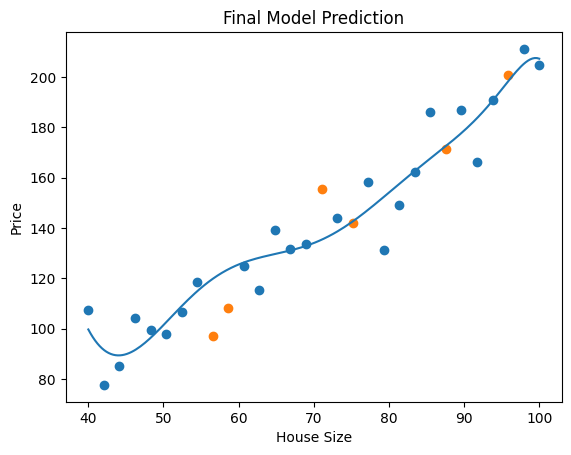

In [5]:
X_line = np.linspace(40, 100, 200).reshape(-1, 1)
X_line_poly = poly.transform(X_line)
y_line = model.predict(X_line_poly)

plt.scatter(X_train, y_train)
plt.scatter(X_test, y_test)
plt.plot(X_line, y_line)

plt.xlabel("House Size")
plt.ylabel("Price")
plt.title("Final Model Prediction")
plt.show()
